# Calibrate H5 File Workflow

Run HDF5 calibration and inspect the fitted per-channel timing/lifetime outputs.


In [1]:
from pathlib import Path
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
while not (repo_root / "src").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from brighteyes_mcs_file import calibrate_h5_file, show_h5_structure_html
import brighteyes_mcs_file.graph as graph

EXPECTED_H5_DATA_FORMAT_VERSION = "0.0.6"


def assert_h5_schema_version(filename, expected=EXPECTED_H5_DATA_FORMAT_VERSION):
    with h5py.File(filename, "r") as hf:
        actual = hf.attrs["data_format_version"]
    actual = actual.decode() if isinstance(actual, bytes) else str(actual)
    if actual != expected:
        raise ValueError(f"Expected H5 schema version {expected}, found {actual} in {filename}")
    return actual


## Calibration Parameters


In [2]:
data_key = "data"
data_keys = (data_key,) if isinstance(data_key, str) else tuple(data_key)
inspect_data_key = data_keys[0]

data_folder = Path(
    "/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide"
)
measurement_file = data_folder / "03_Convallaria_DFD_40MHz-17-03-2026-17-07-20.h5"
reference_file = data_folder / "FLIMLABS_Yellow_slide_2_5ns-17-03-2026-16-18-22.h5"

tau_reference_ns = 2.5
reference_type = "ref"
fit_mode = "model_shift"
fit_type = "likelihood"
laser_period_ns = None

channel_skew = {
    "type": "phase_cross_correlation",
    "source": "ref",
    "reference_channel": 12,
    "upsampling": 10,
    "apodize": False,
}

overwrite_existing = True


## Run Calibration


In [3]:
output_path = calibrate_h5_file(
    measurement_file,
    reference_file,
    data_key=data_key,
    reference_type=reference_type,
    tau_ref=tau_reference_ns,
    fit_mode=fit_mode,
    fit_type=fit_type,
    channel_skew_type=channel_skew["type"],
    channel_skew_source=channel_skew["source"],
    channel_skew_fit_reference_channel=channel_skew["reference_channel"],
    channel_skew_fit_upsampling=channel_skew["upsampling"],
    channel_skew_fit_apodize=channel_skew["apodize"],
    period_ns=laser_period_ns,
    overwrite=overwrite_existing,
    create_output=True,
)

output_path = Path(output_path)
h5_schema_version = assert_h5_schema_version(output_path)
output_path


Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

PosixPath('/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/03_Convallaria_DFD_40MHz-17-03-2026-17-07-20_calib.h5')

## Load Calibration Tables


In [4]:
PRODUCT_NAME_BY_DATA_KEY = {
    "data": "spad",
    "spad": "spad",
    "raw/spad": "spad",
    "data_channels_extra": "aux",
    "aux": "aux",
    "raw/aux": "aux",
}

SUMMARY_DATASETS = {
    "channel": "channels/index",
    "reference_mask": "channels/reference_mask",
    "amplitude": "fit/amplitude",
    "amplitude_err": "fit/amplitude_err",
    "tau_ns": "fit/tau_ns",
    "tau_err_ns": "fit/tau_err_ns",
    "tau_reference_ns": "fit/tau_reference_ns",
    "fitted_delay_bins": "fit/fitted_delay_bins",
    "fitted_delay_ns": "fit/fitted_delay_ns",
    "delay_correction_bins": "timing/delay_correction_bins",
    "delay_correction_err_bins": "timing/delay_correction_err_bins",
    "fitted_delay_err_bins": "fit/fitted_delay_err_bins",
    "delay_correction_ns": "timing/delay_correction_ns",
    "delay_correction_err_ns": "timing/delay_correction_err_ns",
    "fitted_delay_err_ns": "fit/fitted_delay_err_ns",
    "channel_skew": "timing/channel_skew_bins",
    "channel_skew_err": "timing/channel_skew_err_bins",
    "residual_error": "fit/residual_error",
}


def calibration_product_name(source_key):
    normalized_key = str(source_key).strip("/")
    return PRODUCT_NAME_BY_DATA_KEY[normalized_key]


def calibration_result_group(handle, source_key=inspect_data_key, calibration_key="calibration"):
    product_name = calibration_product_name(source_key)
    results_path = f"{calibration_key}/results"
    result_path = f"{results_path}/{product_name}"
    return handle[result_path]


def read_calibration_summary(result_group):
    return pd.DataFrame(
        {
            column_name: result_group[dataset_path][()]
            for column_name, dataset_path in SUMMARY_DATASETS.items()
        }
    )


with h5py.File(output_path, "r") as h5_file:
    result_group = calibration_result_group(h5_file)
    summary_df = read_calibration_summary(result_group)

summary_df


,channel,reference_mask,amplitude,amplitude_err,tau_ns,tau_err_ns,tau_reference_ns,fitted_delay_bins,fitted_delay_ns,delay_correction_bins,fitted_delay_err_bins,delay_correction_ns,fitted_delay_err_ns,channel_skew,channel_skew_err,residual_error
0,0,0,1.0,0.000587,1.866209,0.001387,2.5,-4.207430,-1.155887,-4.110588,0.002745,-1.129282,0.000754,2.491103e-01,NaN,0.002800
1,1,1,1.0,0.000550,1.872188,0.001277,2.5,-4.170332,-1.145696,-4.110588,0.002440,-1.129282,0.000670,-1.464411e+00,NaN,0.002718
2,2,2,1.0,0.000541,1.901201,0.001253,2.5,-4.161206,-1.143188,-4.110588,0.002342,-1.129282,0.000643,-1.592118e+00,NaN,0.002740
3,3,3,1.0,0.000568,1.934812,0.001327,2.5,-4.113454,-1.130070,-4.110588,0.002333,-1.129282,0.000641,2.867254e-01,NaN,0.002678
4,4,4,1.0,0.000617,1.992450,0.001481,2.5,-4.148490,-1.139695,-4.110588,0.002729,-1.129282,0.000750,-2.552994e-01,NaN,0.002689
5,5,5,1.0,0.000535,1.861954,0.001201,2.5,-4.106753,-1.128229,-4.110588,0.002139,-1.129282,0.000588,-1.295705e-01,NaN,0.002711
6,6,6,1.0,0.000475,1.808335,0.001059,2.5,-4.168316,-1.145142,-4.110588,0.002056,-1.129282,0.000565,-1.736258e-01,NaN,0.002844
7,7,7,1.0,0.000474,1.818680,0.001057,2.5,-4.121364,-1.132243,-4.110588,0.001985,-1.129282,0.000545,-4.965447e-01,NaN,0.002736
8,8,8,1.0,0.000503,1.890324,0.001140,2.5,-4.073976,-1.119224,-4.110588,0.001921,-1.129282,0.000528,-4.860807e-01,NaN,0.002763
9,9,9,1.0,0.000577,1.952913,0.001370,2.5,-4.117090,-1.131069,-4.110588,0.002451,-1.129282,0.000673,6.032639e-02,NaN,0.002540


## Channel Fit Summary


(<Figure size 1200x600 with 4 Axes>,
 (<Axes: title={'center': 'Calibration lifetime by channel'}, ylabel='Lifetime (ns)'>,
  <Axes: title={'center': 'Lifetime distribution'}, xlabel='Channel count'>,
  <Axes: xlabel='Channel', ylabel='Fit RMSE'>))

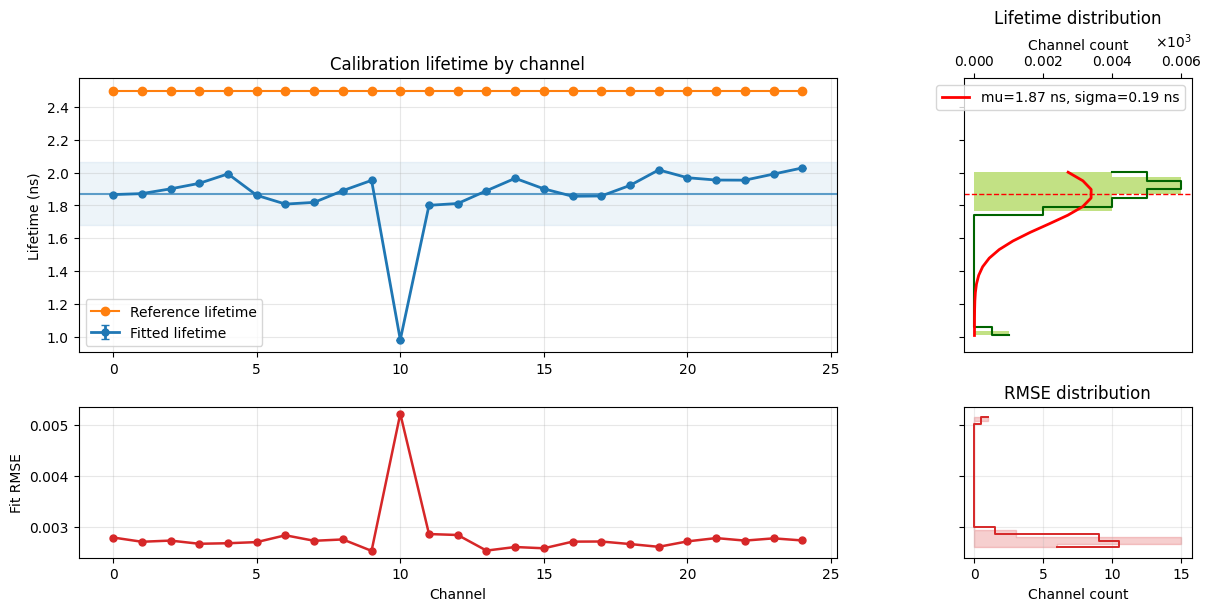

In [5]:
graph.plot_calibration_lifetime_summary(summary_df)


(<Figure size 1600x640 with 4 Axes>,
 (<Axes: title={'center': 'Channel skew'}, ylabel='Channel skew (bins)'>,
  <Axes: title={'center': 'Fitted common delay'}, xlabel='Channel', ylabel='Common delay (ns)'>))

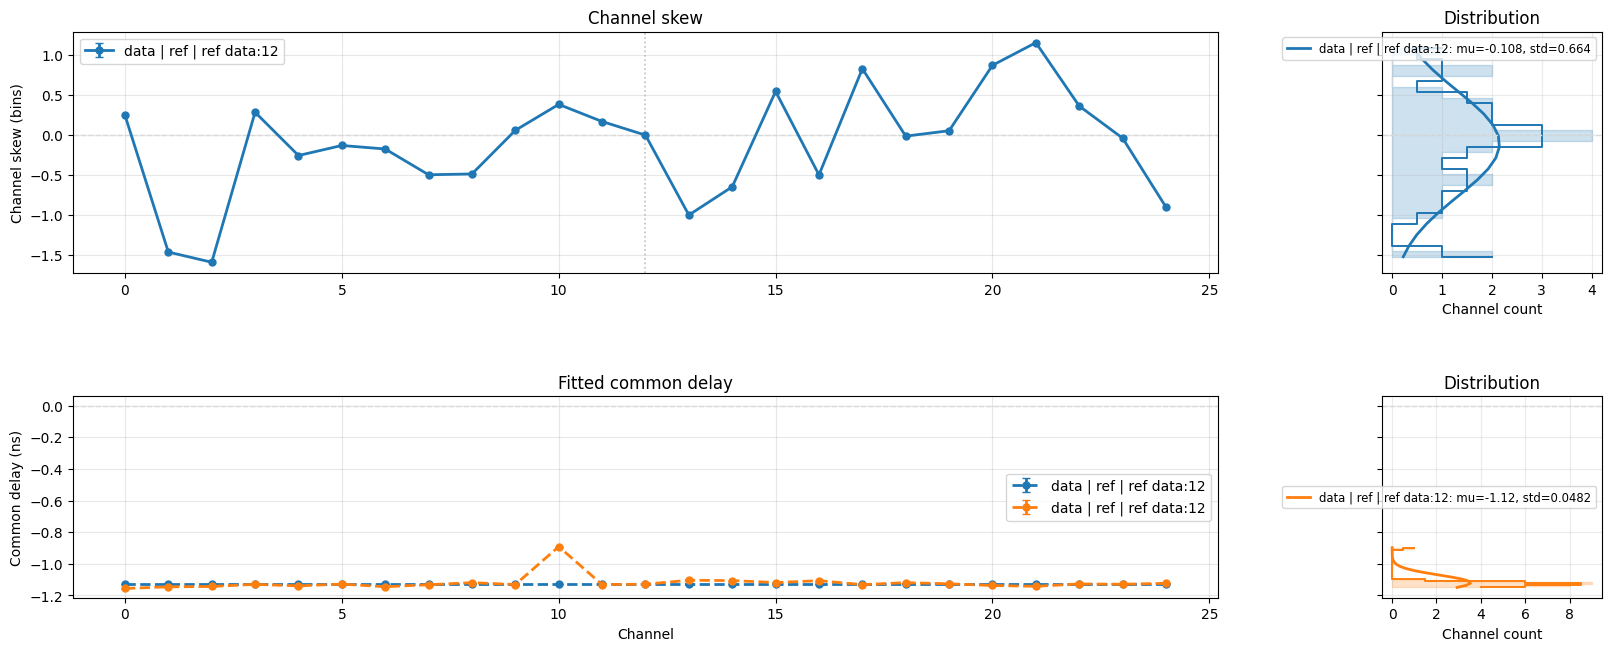

In [6]:
summary_tables = []
plot_labels = []

with h5py.File(output_path, "r") as h5_file:
    for source_key in data_keys:
        result_group = calibration_result_group(h5_file, source_key=source_key)
        summary_tables.append(read_calibration_summary(result_group))

        skew_source = result_group.attrs["channel_skew_source"]
        reference_key = result_group.attrs["channel_skew_fit_reference_data_key"]
        reference_channel = result_group.attrs["channel_skew_fit_reference_channel_resolved"]
        plot_labels.append(f"{source_key} | {skew_source} | ref {reference_key}:{reference_channel}")

graph.plot_calibration_shift_summary(
    summary_tables,
    labels=plot_labels,
    reference_channel=channel_skew["reference_channel"],
)


## Inspect One Channel Fit


<Axes: title={'center': 'Channel 12: tau=1.81 ns, delay=-1.13 ns, RMSE=0.00285'}, xlabel='Time (ns)', ylabel='Normalized counts'>

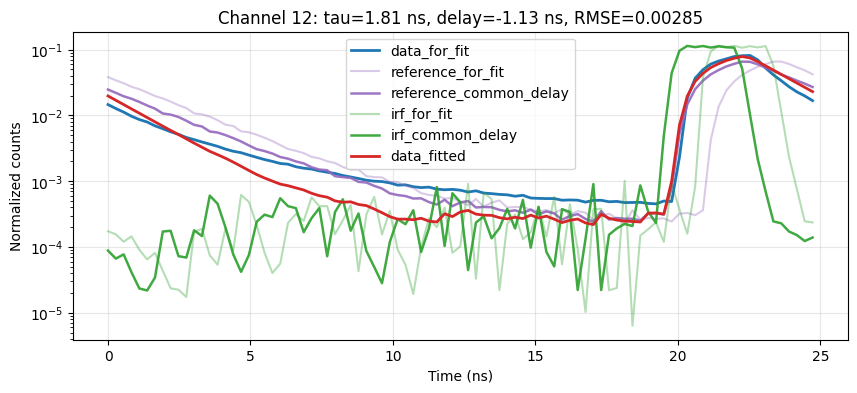

In [7]:
channel = 12


def read_trace(result_group, dataset_path, column):
    return result_group[dataset_path][:, column]


with h5py.File(output_path, "r") as h5_file:
    result_group = calibration_result_group(h5_file)
    channel_indices = result_group["channels/index"][()]
    matching_columns = np.flatnonzero(channel_indices == channel)

    if len(matching_columns) == 0:
        raise ValueError(f"Channel {channel} is not present in {channel_indices.tolist()}")

    column = int(matching_columns[0])
    time_ns = h5_file["calibration/axes/time_ns"][:]

    traces = {
        "measured_trace": read_trace(result_group, "fit/measured_trace", column),
        "reference_trace": read_trace(result_group, "fit/reference_trace", column),
        "aligned_reference_trace": read_trace(
            result_group,
            "aligned/reference_trace",
            column,
        ),
        "irf_trace": read_trace(result_group, "fit/irf_trace", column),
        "aligned_irf_trace": read_trace(result_group, "aligned/irf_trace", column),
        "fitted_trace": read_trace(result_group, "fit/fitted_trace", column),
    }

    tau_ns = float(result_group["fit/tau_ns"][column])
    delay_ns = float(result_group["timing/delay_correction_ns"][column])
    residual_error = float(result_group["fit/residual_error"][column])

fig, ax = plt.subplots(figsize=(10, 4))
graph.plot_calibration_fit_traces(
    time_ns,
    traces,
    title=f"Channel {channel}: tau={tau_ns:.2f} ns, delay={delay_ns:.2f} ns, RMSE={residual_error:.3g}",
    ax=ax,
)


## HDF5 Structure


In [8]:
print(output_path)
show_h5_structure_html(output_path)


/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/03_Convallaria_DFD_40MHz-17-03-2026-17-07-20_calib.h5


'<div class="h5-tree">\n  <style>\n    .h5-tree {\n      color-scheme: light dark;\n      font-family: "Menlo", "Consolas", "DejaVu Sans Mono", monospace;\n      font-size: 13px;\n      line-height: 1.5;\n      color: var(--h5-fg);\n      --h5-fg: #1f2937;\n      --h5-muted: #6b7280;\n      --h5-border: #d1d5db;\n      --h5-group: #0f766e;\n      --h5-dataset: #1d4ed8;\n      --h5-attrs: #7c2d12;\n      --h5-node-ref: #7c3aed;\n      --h5-attr-key: #b45309;\n      --h5-attr-value: #374151;\n      --h5-root: #111827;\n    }\n    @media (prefers-color-scheme: dark) {\n      .h5-tree {\n        --h5-fg: #e5e7eb;\n        --h5-muted: #9ca3af;\n        --h5-border: #4b5563;\n        --h5-group: #5eead4;\n        --h5-dataset: #93c5fd;\n        --h5-attrs: #fdba74;\n        --h5-node-ref: #c4b5fd;\n        --h5-attr-key: #fbbf24;\n        --h5-attr-value: #f3f4f6;\n        --h5-root: #f9fafb;\n      }\n    }\n    .h5-tree ul {\n      list-style: none;\n            margin: 0.2rem 0 0.2rem 1.1